# 2. High Dimensional Analysis & Visualization
This notebook covers:
- PCA with Image Complexity Mapping
- **Image Overlay**: Visualizing movie frames on the neural manifold
- **UMAP**: Non-linear dimensionality reduction
- **Clustering**: Identifying distinct neural states

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.offsetbox import OffsetImage, AnnotationBbox
from allensdk.brain_observatory.ecephys.ecephys_project_cache import EcephysProjectCache
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import umap
import plotly.express as px

# Setup
%matplotlib inline
plt.rcParams['figure.figsize'] = [12, 8]

# Load Data (Simplified)
output_dir = "../Dataset/RAW"
manifest_path = os.path.join(output_dir, "manifest.json")
cache = EcephysProjectCache.from_warehouse(manifest=manifest_path)
session_id = 750749662
session = cache.get_session_data(session_id)

# Get Response Matrix
stimulus_name = "natural_movie_one"
movie_table = session.get_stimulus_table(stimulus_name)
frame_duration = movie_table['duration'].mean()
units = session.units
spike_counts = session.presentationwise_spike_counts(
    stimulus_presentation_ids=movie_table.index.values,
    bin_edges=np.array([0, frame_duration]),
    unit_ids=units.index.values
)
response_matrix_all = spike_counts.sum(dim="time_relative_to_stimulus_onset")
df_response = pd.DataFrame(response_matrix_all.values, index=movie_table.index, columns=units.index)
df_response['frame'] = movie_table['frame']
average_response_matrix = df_response.groupby('frame').mean()
X = average_response_matrix.values
print("Data Loaded.")

/opt/anaconda3/envs/TDA/lib/python3.11/site-packages/hdmf/spec/namespace.py:590: UserWarning: Ignoring the following cached namespace(s) because another version is already loaded:
core - cached version: 2.2.2, loaded version: 2.7.0
The loaded extension(s) may not be compatible with the cached extension(s) in the file. Please check the extension documentation and ignore this warning if these versions are compatible.
  self.warn_for_ignored_namespaces(ignored_namespaces)


Data Loaded.


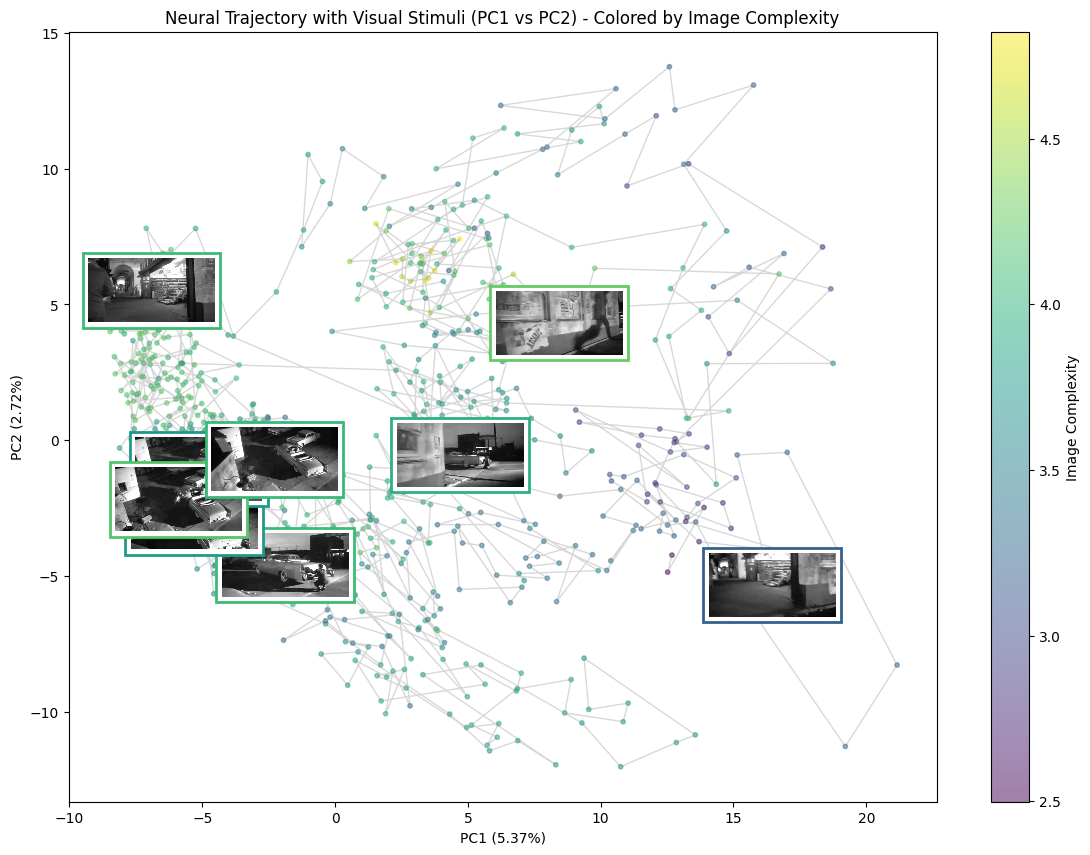

In [2]:
# PCA & Image Complexity
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
pca = PCA(n_components=3)
X_pca = pca.fit_transform(X_scaled)

# Load Movie Template
movie_template = cache.get_natural_movie_template(1)

# Calculate Image Complexity (Gradient Magnitude)
def get_image_complexity(img):
    gy, gx = np.gradient(img)
    gnorm = np.sqrt(gx**2 + gy**2)
    return np.mean(gnorm)

frame_complexity = np.array([get_image_complexity(frame) for frame in movie_template])
min_c, max_c = frame_complexity.min(), frame_complexity.max()

# Plot PCA with Image Overlay
fig, ax = plt.subplots(figsize=(14, 10))
sc = ax.scatter(X_pca[:, 0], X_pca[:, 1], c=frame_complexity, cmap='viridis', s=10, alpha=0.5)
ax.plot(X_pca[:, 0], X_pca[:, 1], color='gray', alpha=0.3, linewidth=1)

# Overlay Images every 100 frames
interval = 100
zoom = 0.15
total_frames = len(movie_template)

for i in range(0, total_frames, interval):
    x, y = X_pca[i, 0], X_pca[i, 1]
    img = movie_template[i, :, :]
    im = OffsetImage(img, zoom=zoom, cmap='gray')
    
    # Border color by complexity
    norm_complexity = (frame_complexity[i] - min_c) / (max_c - min_c)
    color = plt.cm.viridis(norm_complexity)
    
    ab = AnnotationBbox(im, (x, y), xycoords='data', frameon=True,
                        bboxprops=dict(edgecolor=color, linewidth=2))
    ax.add_artist(ab)

ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.2%})')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.2%})')
ax.set_title('Neural Trajectory with Visual Stimuli (PC1 vs PC2) - Colored by Image Complexity')
plt.colorbar(sc, label='Image Complexity')
plt.show()

In [3]:
# UMAP & Clustering
print("Running UMAP...")
reducer = umap.UMAP(n_components=3, n_neighbors=15, min_dist=0.1, random_state=42)
embedding_3d = reducer.fit_transform(X_pca)

# KMeans Clustering
n_clusters = 5
kmeans = KMeans(n_clusters=n_clusters, random_state=42)
labels = kmeans.fit_predict(X_pca)

# Interactive 3D Plot
fig = px.scatter_3d(
    x=embedding_3d[:, 0], y=embedding_3d[:, 1], z=embedding_3d[:, 2],
    color=labels,
    title="3D UMAP of Neural Activity (Colored by Cluster)",
    labels={'color': 'Cluster ID'}
)
fig.update_traces(marker=dict(size=3))
fig.show()

Running UMAP...
